In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image

In [2]:
from network import Truncated_VGG
from training import loss_fn, generating_image

In [3]:
def image_loader(path):
    image = Image.open(path)
    processing = transforms.Compose([transforms.Resize((512,512)),transforms.ToTensor()])
    return processing(image)

In [4]:
original_image = image_loader("./images/venice-boat.jpg")
style_image = image_loader("./images/shipwreck.jpg")

In [5]:
pretrained_vgg_model = models.vgg19(pretrained=True).features
trunc_model = Truncated_VGG(pretrained_vgg_model[:29])

/Users/divyanshubhatt/opt/miniconda3/envs/pytorch_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/divyanshubhatt/opt/miniconda3/envs/pytorch_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
generated_image = generating_image(original_image, style_image, trunc_model)

Epoch: 0 | Loss 33823600.0
Saving generated_image: 0
Epoch: 25 | Loss 6011230.5
Epoch: 50 | Loss 2774388.0
Epoch: 75 | Loss 1506545.25
Epoch: 100 | Loss 925535.8125
Epoch: 125 | Loss 623264.25
Epoch: 150 | Loss 451663.1875
Epoch: 175 | Loss 348126.5625
Epoch: 200 | Loss 282633.40625
Saving generated_image: 200
Epoch: 225 | Loss 239290.078125
Epoch: 250 | Loss 209117.046875
Epoch: 275 | Loss 186957.359375
Epoch: 300 | Loss 169764.84375
Epoch: 325 | Loss 155817.328125
Epoch: 350 | Loss 144113.984375
Epoch: 375 | Loss 134048.875
Epoch: 400 | Loss 125263.53125
Saving generated_image: 400


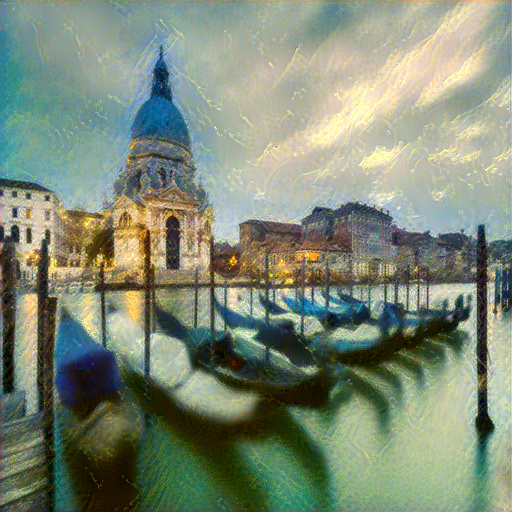

In [10]:
# its hard to see the difference between the below 2 images
display(Image.open("./output/generated-image200.png"))

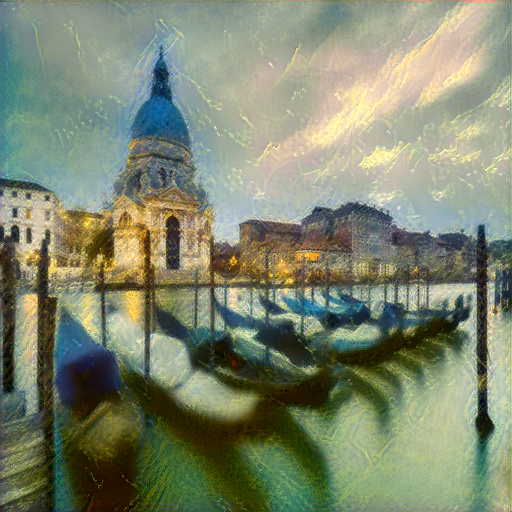

In [11]:
display(Image.open("./output/generated-image400.png"))